##Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

# Install skfuzzy if not already installed
try:
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
except ImportError:
    !pip install -q scikit-fuzzy
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:00


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

Shape: (973, 15)

Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Data types:
 Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object


In [3]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


##Data Cleaning

In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Duplicate rows: 0


In [5]:
# Categorical variables
print("Gender:", df['Gender'].unique())
print("Workout_Type:", df['Workout_Type'].unique())
print("Experience_Level:", sorted(df['Experience_Level'].unique()))

Gender: ['Male' 'Female']
Workout_Type: ['Yoga' 'HIIT' 'Cardio' 'Strength']
Experience_Level: [np.int64(1), np.int64(2), np.int64(3)]


In [6]:
# numerical ranges for possible outliers/inconsistent values
num_cols = ['Age','Weight (kg)','Height (m)','Max_BPM','Avg_BPM','Resting_BPM',
            'Session_Duration (hours)','Calories_Burned','Fat_Percentage',
            'Water_Intake (liters)','Workout_Frequency (days/week)','BMI']
df[num_cols].agg(['min','max']).T

,min,max
Age,18.00,59.00
Weight (kg),40.00,129.90
Height (m),1.50,2.00
Max_BPM,160.00,199.00
Avg_BPM,120.00,169.00
Resting_BPM,50.00,74.00
Session_Duration (hours),0.50,2.00
Calories_Burned,303.00,1783.00
Fat_Percentage,10.00,35.00
Water_Intake (liters),1.50,3.70


In [7]:
# Logical consistency check: Resting_BPM should be < Avg_BPM <= Max_BPM
inconsistent = df[(df['Resting_BPM'] >= df['Avg_BPM']) | (df['Avg_BPM'] > df['Max_BPM'])]
print("Rows with inconsistent BPM ordering:", len(inconsistent))

Rows with inconsistent BPM ordering: 23


##EDA

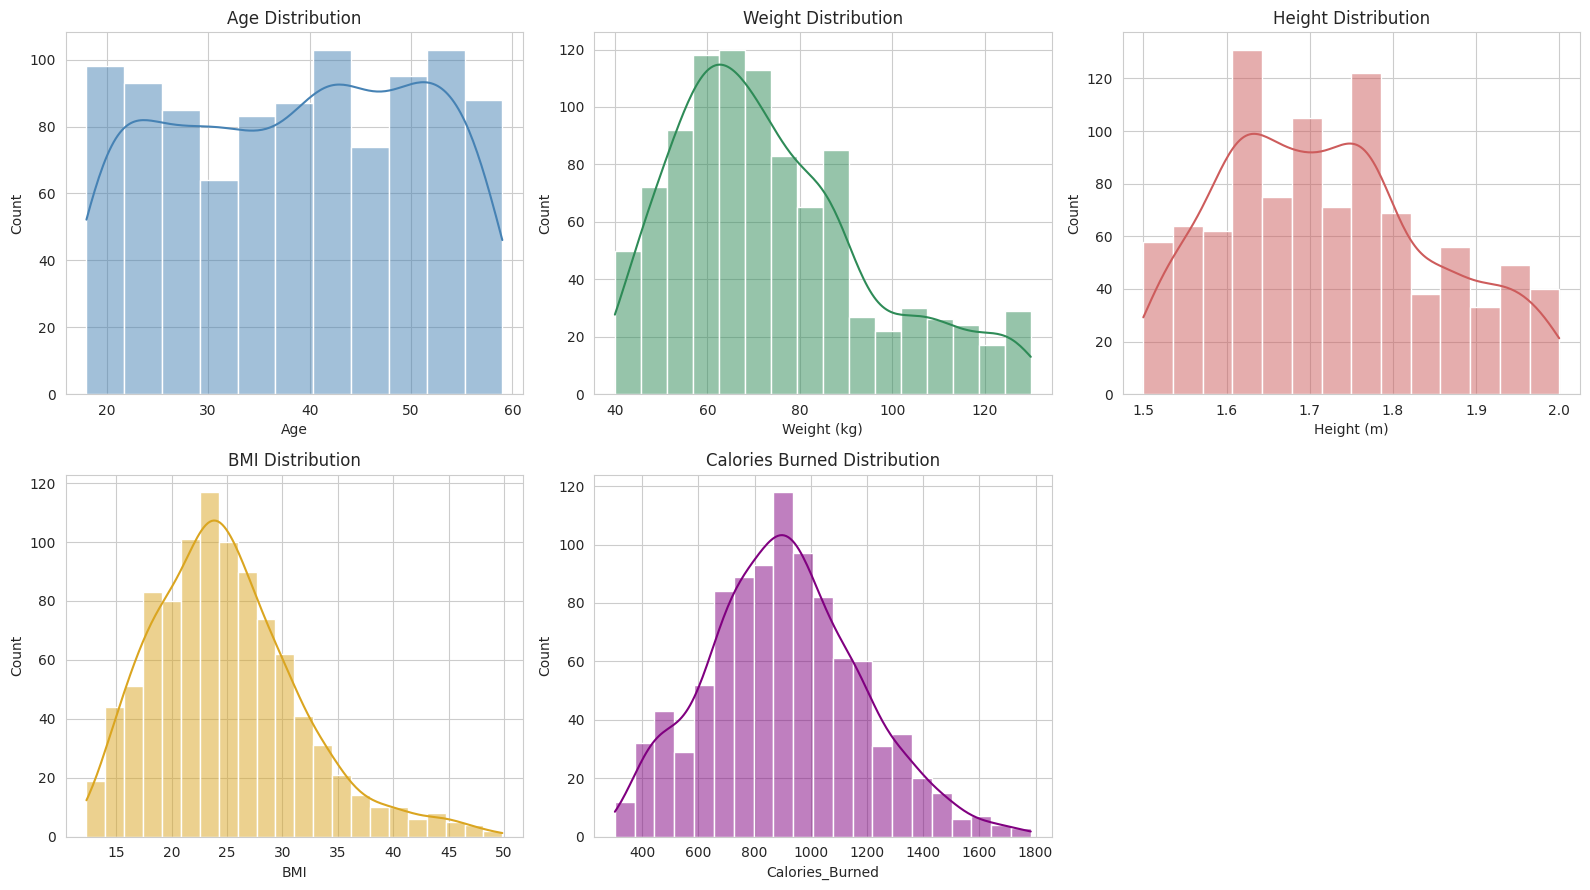

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.histplot(df['Age'], kde=True, ax=axes[0,0], color='steelblue').set_title('Age Distribution')
sns.histplot(df['Weight (kg)'], kde=True, ax=axes[0,1], color='seagreen').set_title('Weight Distribution')
sns.histplot(df['Height (m)'], kde=True, ax=axes[0,2], color='indianred').set_title('Height Distribution')
sns.histplot(df['BMI'], kde=True, ax=axes[1,0], color='goldenrod').set_title('BMI Distribution')
sns.histplot(df['Calories_Burned'], kde=True, ax=axes[1,1], color='purple').set_title('Calories Burned Distribution')
axes[1,2].axis('off')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100)
plt.show()

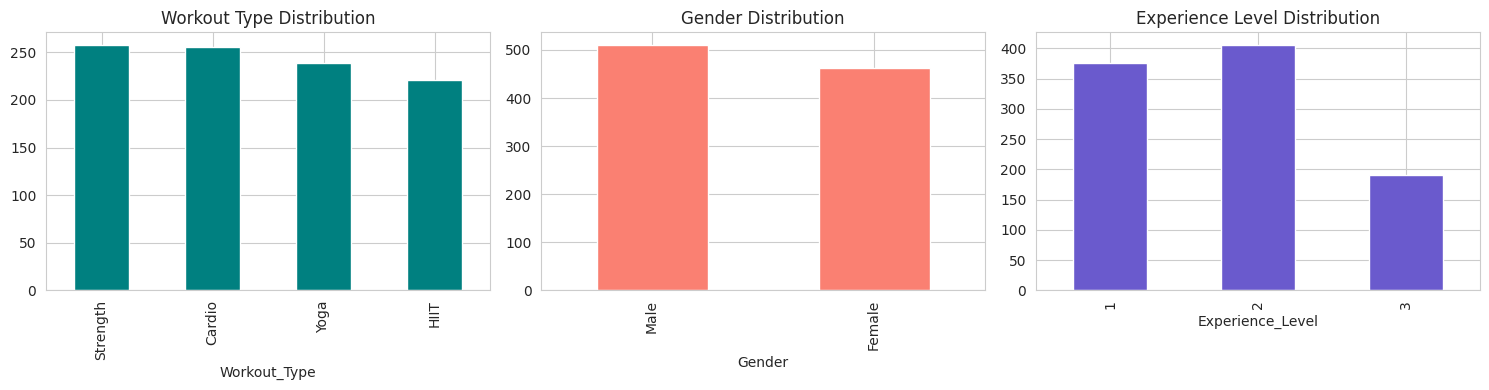

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['Workout_Type'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Workout Type Distribution')
df['Gender'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Gender Distribution')
df['Experience_Level'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='slateblue')
axes[2].set_title('Experience Level Distribution')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100)
plt.show()

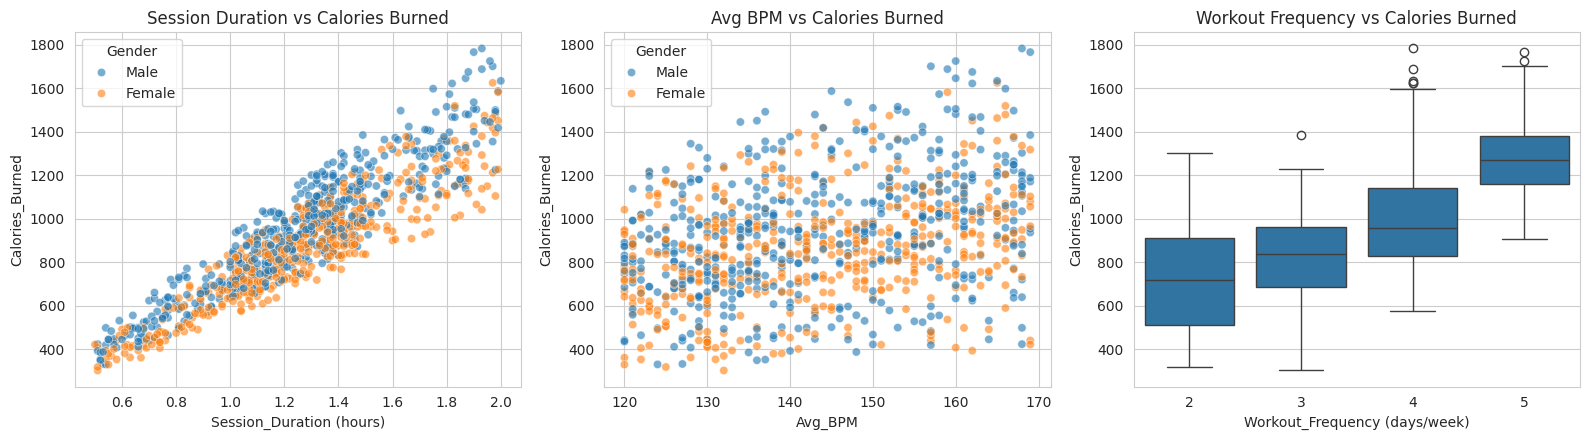

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=df, x='Session_Duration (hours)', y='Calories_Burned', hue='Gender', ax=axes[0], alpha=0.6)
axes[0].set_title('Session Duration vs Calories Burned')
sns.scatterplot(data=df, x='Avg_BPM', y='Calories_Burned', hue='Gender', ax=axes[1], alpha=0.6)
axes[1].set_title('Avg BPM vs Calories Burned')
sns.boxplot(data=df, x='Workout_Frequency (days/week)', y='Calories_Burned', ax=axes[2])
axes[2].set_title('Workout Frequency vs Calories Burned')
plt.tight_layout()
plt.savefig('eda_relationships.png', dpi=100)
plt.show()

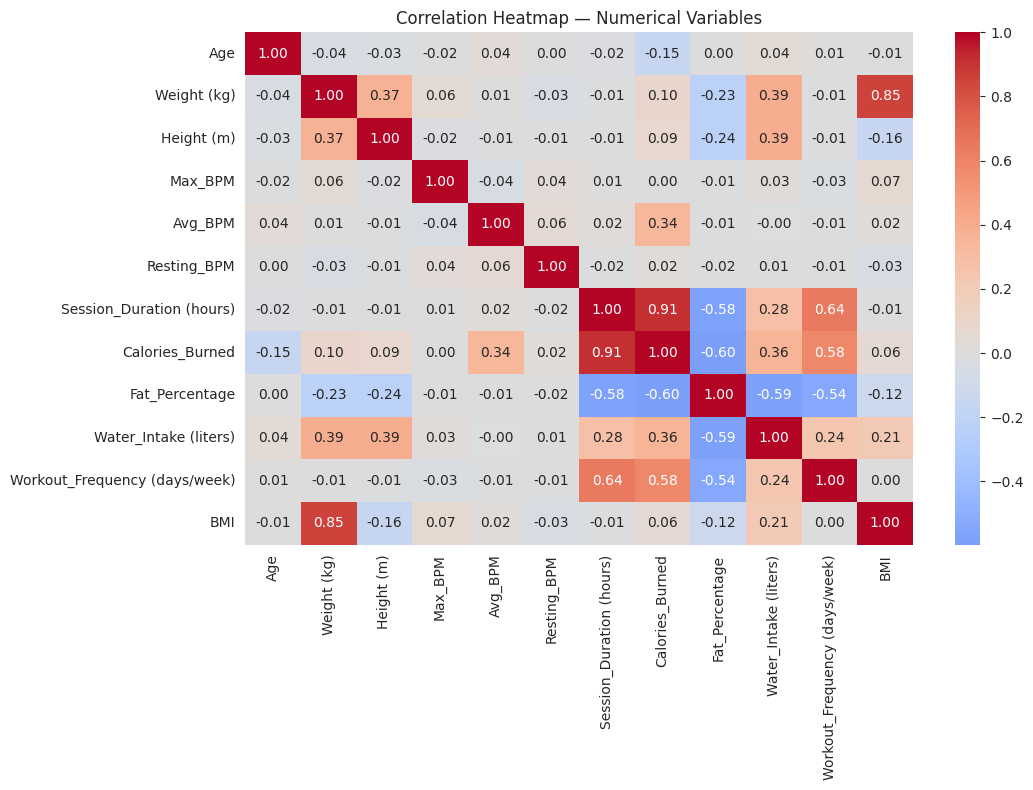

In [11]:
plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numerical Variables')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100)
plt.show()

**Interpretation:**
- Session Duration shows the strongest positive correlation with Calories Burned — the primary driver of the ANN's prediction.
- Avg_BPM also correlates positively with Calories Burned, consistent with higher-intensity effort burning more calories.
- Workout Frequency shows a milder positive relationship — more sessions per week associate with slightly higher per-session burn, likely tied to experience level.
- BMI and Fat_Percentage are correlated with each other but show weaker direct correlation with Calories_Burned, so they mainly support the Fuzzy system rather than dominating the ANN.

##Feature Engineering

`Workout_Type` is excluded from the baseline ANN (it's a categorical training-style label, not a strong numeric predictor of a single session's calorie burn) — a one-hot-encoded comparison version is included at the end of this step for completeness.

In [12]:
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])
print("Gender encoding:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

FEATURES = ['Age', 'Gender_Encoded', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
            'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage',
            'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
TARGET = 'Calories_Burned'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
Train shape: (778, 13)  Test shape: (195, 13)


In [13]:
import os

# Create the models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Fit scaler ONLY on training data -> transform both train and test (avoids data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'models/fitness_scaler.pkl')
joblib.dump(FEATURES, 'models/feature_columns.pkl')
joblib.dump(le_gender, 'models/gender_encoder.pkl')
print("Scaler, feature list, and gender encoder saved to models/")

Scaler, feature list, and gender encoder saved to models/


##  Artificial Neural Network (Calories Burned Prediction)
Simple feed-forward regression network: Dense(64)→ReLU→Dense(32)→ReLU→Dropout→Dense(16)→ReLU→Dense(1, linear).

In [14]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # linear output for regression
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)
print(f"Training stopped after {len(history.history['loss'])} epochs (EarlyStopping).")

Training stopped after 200 epochs (EarlyStopping).


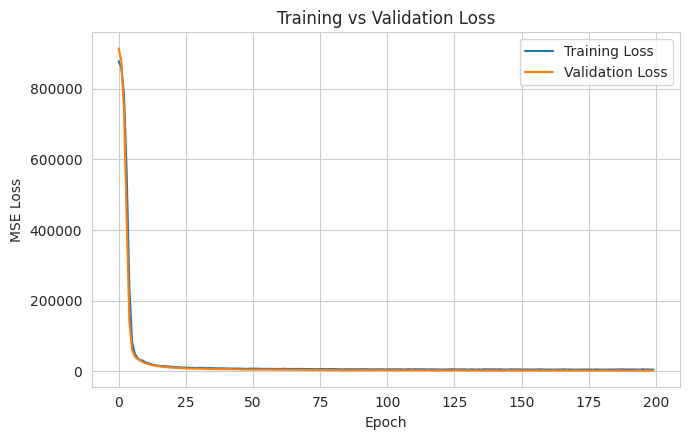

In [16]:
plt.figure(figsize=(7, 4.5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Training vs Validation Loss')
plt.legend(); plt.tight_layout()
plt.savefig('ann_loss_curve.png', dpi=100)
plt.show()

In [17]:
y_pred = model.predict(X_test_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} kcal   (avg. absolute prediction error)")
print(f"MSE  : {mse:.2f}        (squared error, penalizes large misses)")
print(f"RMSE : {rmse:.2f} kcal  (error in original kcal units)")
print(f"R2   : {r2:.4f}         (proportion of variance explained by the model)")

MAE  : 28.22 kcal   (avg. absolute prediction error)
MSE  : 1373.56        (squared error, penalizes large misses)
RMSE : 37.06 kcal  (error in original kcal units)
R2   : 0.9835         (proportion of variance explained by the model)


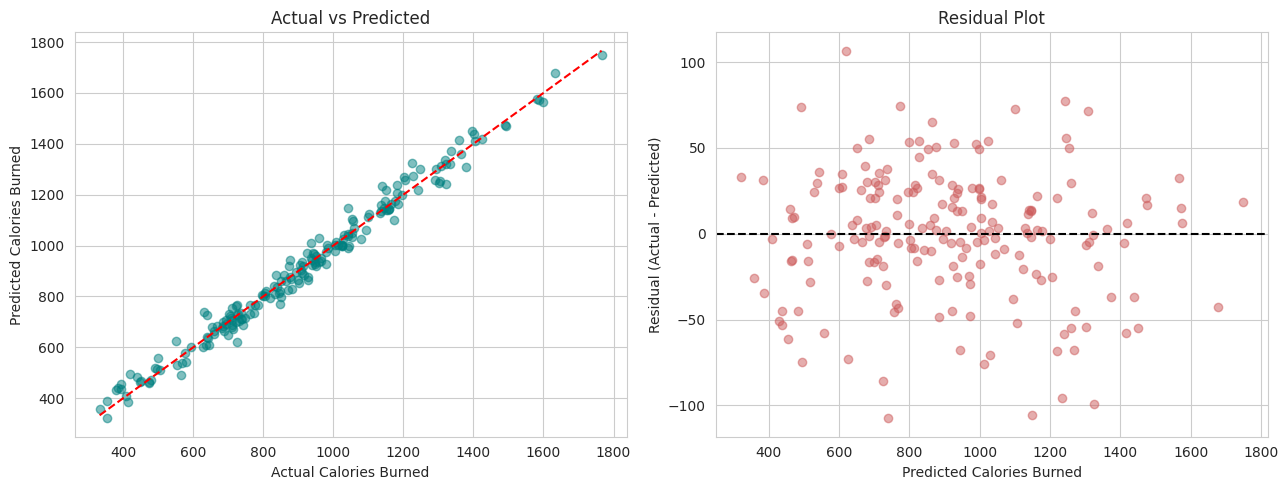

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Calories Burned'); axes[0].set_ylabel('Predicted Calories Burned')
axes[0].set_title('Actual vs Predicted')

residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='indianred')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Calories Burned'); axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('ann_predictions.png', dpi=100)
plt.show()

In [19]:
model.save('models/fitness_ann_model.keras')
print("ANN model saved to models/fitness_ann_model.keras")

ANN model saved to models/fitness_ann_model.keras


## Fuzzy Logic System (Workout Intensity)
Inputs: **BMI**, **Workout Frequency**, **Experience Level**. Output: **Workout Intensity** (0–100, defuzzified via centroid), read as Light / Moderate / High.

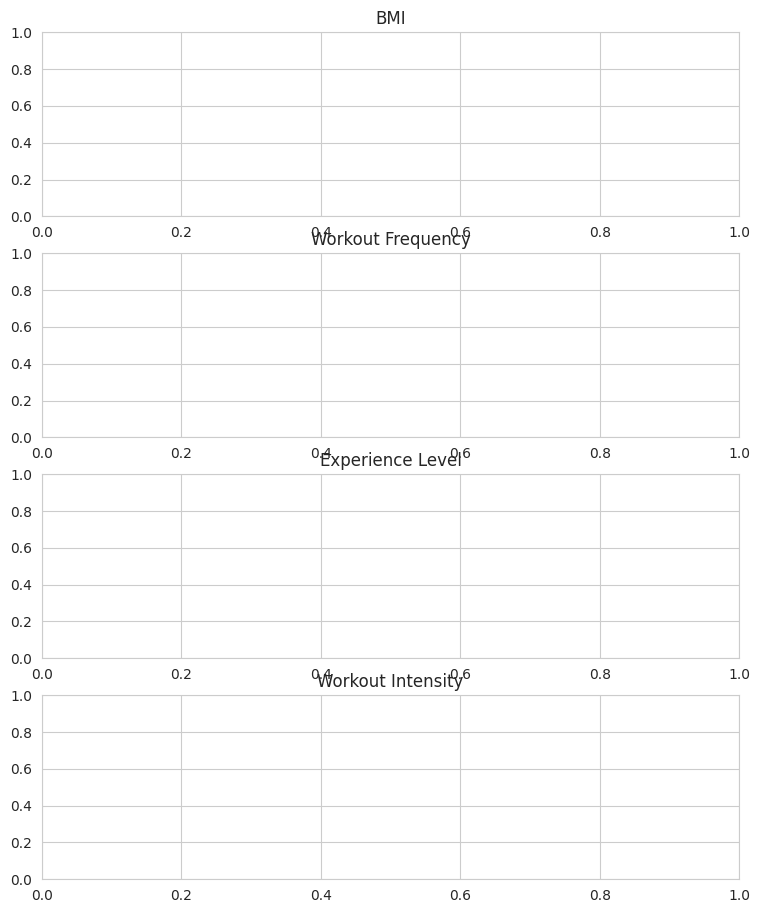

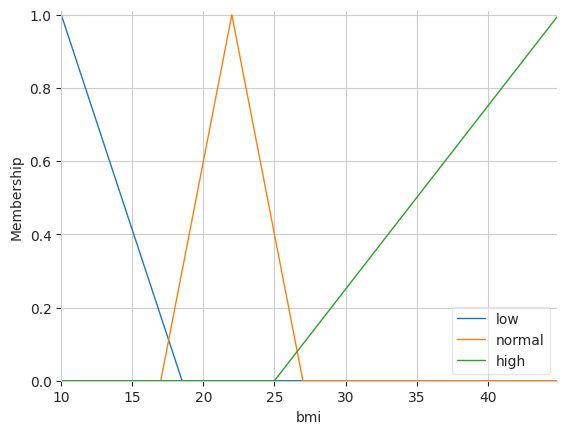

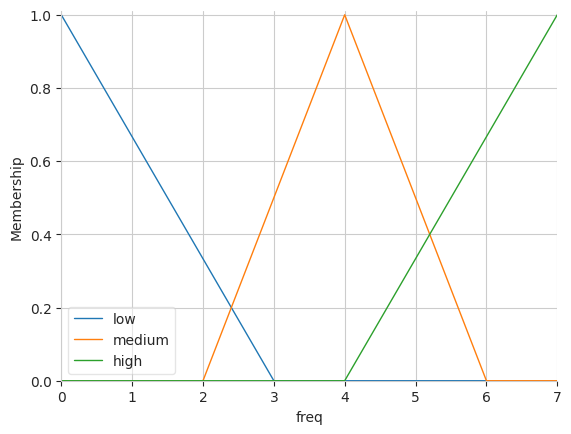

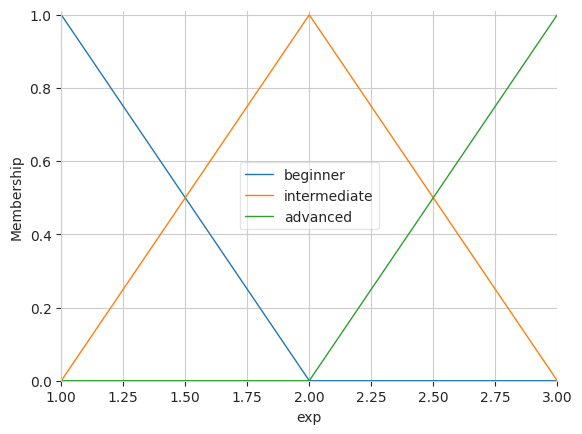

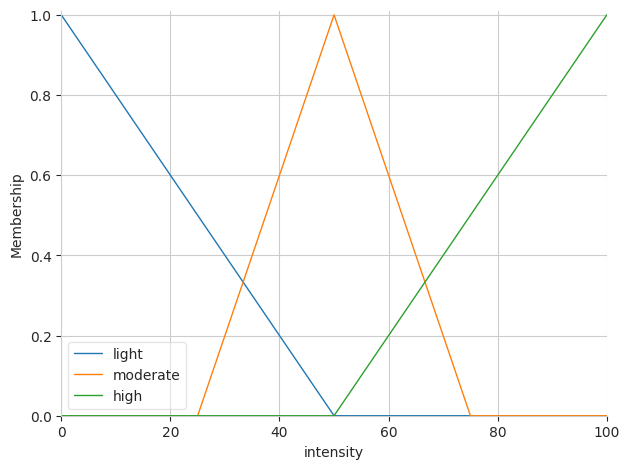

In [20]:
bmi_in = ctrl.Antecedent(np.arange(10, 45, 0.1), 'bmi')
freq_in = ctrl.Antecedent(np.arange(0, 8, 1), 'freq')
exp_in = ctrl.Antecedent(np.arange(1, 4, 1), 'exp')
intensity_out = ctrl.Consequent(np.arange(0, 101, 1), 'intensity')

# Membership functions
bmi_in['low'] = fuzz.trimf(bmi_in.universe, [10, 10, 18.5])
bmi_in['normal'] = fuzz.trimf(bmi_in.universe, [17, 22, 27])
bmi_in['high'] = fuzz.trimf(bmi_in.universe, [25, 45, 45])

freq_in['low'] = fuzz.trimf(freq_in.universe, [0, 0, 3])
freq_in['medium'] = fuzz.trimf(freq_in.universe, [2, 4, 6])
freq_in['high'] = fuzz.trimf(freq_in.universe, [4, 7, 7])

exp_in['beginner'] = fuzz.trimf(exp_in.universe, [1, 1, 2])
exp_in['intermediate'] = fuzz.trimf(exp_in.universe, [1, 2, 3])
exp_in['advanced'] = fuzz.trimf(exp_in.universe, [2, 3, 3])

intensity_out['light'] = fuzz.trimf(intensity_out.universe, [0, 0, 50])
intensity_out['moderate'] = fuzz.trimf(intensity_out.universe, [25, 50, 75])
intensity_out['high'] = fuzz.trimf(intensity_out.universe, [50, 100, 100])

fig, axes = plt.subplots(4, 1, figsize=(9, 11))
for ax, var, name in zip(axes, [bmi_in, freq_in, exp_in, intensity_out],
                          ['BMI', 'Workout Frequency', 'Experience Level', 'Workout Intensity']):
    var.view(ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.savefig('fuzzy_membership.png', dpi=100)
plt.show()

In [21]:
# Fuzzy IF-THEN rules (kept conservative -> never pushes an under-qualified user to High intensity)
rule1 = ctrl.Rule(exp_in['beginner'] & freq_in['low'], intensity_out['light'])
rule2 = ctrl.Rule(exp_in['beginner'] & bmi_in['high'], intensity_out['light'])
rule3 = ctrl.Rule(exp_in['beginner'] & freq_in['high'], intensity_out['moderate'])
rule4 = ctrl.Rule(exp_in['intermediate'] & freq_in['medium'], intensity_out['moderate'])
rule5 = ctrl.Rule(exp_in['intermediate'] & bmi_in['high'], intensity_out['moderate'])
rule6 = ctrl.Rule(exp_in['intermediate'] & freq_in['low'], intensity_out['light'])
rule7 = ctrl.Rule(exp_in['advanced'] & freq_in['high'], intensity_out['high'])
rule8 = ctrl.Rule(exp_in['advanced'] & freq_in['medium'], intensity_out['moderate'])
rule9 = ctrl.Rule(exp_in['advanced'] & bmi_in['normal'] & freq_in['high'], intensity_out['high'])
rule10 = ctrl.Rule(bmi_in['low'] & exp_in['beginner'], intensity_out['light'])

rule_list = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10]
intensity_ctrl = ctrl.ControlSystem(rule_list)
print(f"Fuzzy rule base created with {len(rule_list)} rules.")

Fuzzy rule base created with 10 rules.


In [22]:
def get_fuzzy_intensity(bmi_val, freq_val, exp_val):
    """Returns (defuzzified_score, label) for given BMI, weekly frequency, experience level (1-3)."""
    sim = ctrl.ControlSystemSimulation(intensity_ctrl)
    sim.input['bmi'] = float(np.clip(bmi_val, 10, 44.9))
    sim.input['freq'] = float(np.clip(freq_val, 0, 7))
    sim.input['exp'] = float(np.clip(exp_val, 1, 3))
    sim.compute()
    score = sim.output['intensity']
    if score < 40:
        label = 'Light'
    elif score < 65:
        label = 'Moderate'
    else:
        label = 'High'
    return score, label

# Example
score, label = get_fuzzy_intensity(bmi_val=24.5, freq_val=4, exp_val=2)
print(f"Example -> BMI=24.5, Frequency=4, Experience=2 (Intermediate): score={score:.1f} -> {label}")

Example -> BMI=24.5, Frequency=4, Experience=2 (Intermediate): score=50.0 -> Moderate


## Approximation Mode
Lets a user without exact measurements estimate Weight/BMI from **Body Build** + **Height**, and derive an approximate **Activity Level**. Estimates are explicitly labeled as ranges, never presented as exact values.

In [23]:
# Representative BMI midpoints per body-build category (used only as an approximation)
BODY_BUILD_BMI_RANGE = {
    'Slim':      (16.0, 20.0),
    'Average':   (20.0, 25.0),
    'Muscular':  (23.0, 28.0),   # muscle mass raises BMI without high fat
    'Heavy':     (28.0, 35.0),
}

ACTIVITY_FREQ_MAP = {
    'Sedentary':          1,
    'Lightly Active':     2,
    'Moderately Active':  4,
    'Highly Active':      6,
}

def approximate_profile(height_m, body_build, activity_level, workout_experience):
    """Returns an approximate profile dict. All values are explicitly labeled as ESTIMATES."""
    bmi_low, bmi_high = BODY_BUILD_BMI_RANGE[body_build]
    bmi_mid = (bmi_low + bmi_high) / 2
    weight_low = bmi_low * (height_m ** 2)
    weight_high = bmi_high * (height_m ** 2)
    weight_mid = bmi_mid * (height_m ** 2)
    freq_est = ACTIVITY_FREQ_MAP[activity_level]
    exp_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
    exp_est = exp_map[workout_experience]

    return {
        'is_estimate': True,
        'bmi_estimate_range': (round(bmi_low, 1), round(bmi_high, 1)),
        'bmi_representative': round(bmi_mid, 1),
        'weight_estimate_range_kg': (round(weight_low, 1), round(weight_high, 1)),
        'weight_representative_kg': round(weight_mid, 1),
        'workout_frequency_estimate': freq_est,
        'experience_level_estimate': exp_est,
    }

# Example
example = approximate_profile(height_m=1.75, body_build='Average', activity_level='Moderately Active', workout_experience='Intermediate')
example

{'is_estimate': True,
 'bmi_estimate_range': (20.0, 25.0),
 'bmi_representative': 22.5,
 'weight_estimate_range_kg': (61.2, 76.6),
 'weight_representative_kg': 68.9,
 'workout_frequency_estimate': 4,
 'experience_level_estimate': 2}

##  Fitness Goals and Recommendation Engine
Combines ANN calorie prediction, fuzzy workout intensity, and the user's fitness goal into a transparent, rule-based recommendation

In [24]:
GOAL_RULES = {
    'Weight Loss': {
        'workout_focus': 'Cardio + light-moderate resistance training',
        'duration': '30-45 minutes/session',
        'frequency': '4-5 sessions/week',
        'notes': 'Prioritize consistent moderate-intensity cardio; general calorie-awareness is more effective than very high intensity for sustainability.'
    },
    'Muscle Gain': {
        'workout_focus': 'Resistance/strength training with progressive overload',
        'duration': '45-60 minutes/session',
        'frequency': '3-5 sessions/week',
        'notes': 'Allow 48 hours of recovery per muscle group; general protein-aware nutrition supports recovery.'
    },
    'General Fitness': {
        'workout_focus': 'Balanced mix of cardio and strength training',
        'duration': '30-45 minutes/session',
        'frequency': '3-4 sessions/week',
        'notes': 'Variety across workout types supports overall conditioning and adherence.'
    },
    'Endurance': {
        'workout_focus': 'Cardio-focused training (running, cycling, swimming)',
        'duration': '40-60 minutes/session',
        'frequency': '4-6 sessions/week',
        'notes': 'Increase session duration gradually week over week rather than increasing intensity abruptly.'
    },
    'Strength': {
        'workout_focus': 'Resistance/strength-focused routine',
        'duration': '45-60 minutes/session',
        'frequency': '3-4 sessions/week',
        'notes': 'Prioritize recovery between sessions targeting the same muscle groups.'
    },
}

INTENSITY_DURATION_ADJUST = {'Light': -10, 'Moderate': 0, 'High': +10}  # minutes, applied to goal's base range

# ---- Workout type, mapped to the dataset's own Workout_Type categories ----
WORKOUT_TYPE_MAP = {
    'Weight Loss':     {'Light': 'Yoga',     'Moderate': 'Cardio',   'High': 'HIIT'},
    'Muscle Gain':     {'Light': 'Strength', 'Moderate': 'Strength', 'High': 'Strength'},
    'General Fitness': {'Light': 'Yoga',     'Moderate': 'Cardio',   'High': 'HIIT'},
    'Endurance':       {'Light': 'Cardio',   'Moderate': 'Cardio',   'High': 'HIIT'},
    'Strength':        {'Light': 'Strength', 'Moderate': 'Strength', 'High': 'Strength'},
}

# ---- Recovery days/week, driven by fuzzy intensity + workout frequency ----
def get_recovery_days(fuzzy_label, workout_frequency):
    base = {'Light': 1, 'Moderate': 2, 'High': 3}[fuzzy_label]
    if workout_frequency >= 6:
        base += 1          # very high frequency needs an extra recovery day
    return min(base, 4)

# ---- Protein guidance: general sports-nutrition ranges (g/kg body weight/day) ----
PROTEIN_RANGE_G_PER_KG = {
    'Weight Loss':     (1.6, 2.2),   # higher end preserves lean mass in a deficit
    'Muscle Gain':     (1.6, 2.2),
    'General Fitness': (1.2, 1.6),
    'Endurance':       (1.2, 1.6),
    'Strength':        (1.6, 2.0),
}

def get_protein_guidance(goal, weight_kg):
    lo, hi = PROTEIN_RANGE_G_PER_KG[goal]
    return {
        'range_g_per_kg': f'{lo}-{hi} g/kg body weight/day',
        'estimated_daily_grams': f'{round(lo*weight_kg)}-{round(hi*weight_kg)} g/day' if weight_kg else 'N/A',
        'note': 'General sports-nutrition guidance, not a medical/dietetic prescription.'
    }

def generate_recommendation(user_profile, predicted_calories, fuzzy_score, fuzzy_label,
                             goal, workout_frequency, weight_kg=None):
    goal_info = GOAL_RULES[goal]
    recommendation = {
        'fitness_goal': goal,
        'estimated_calories_burned_kcal': round(float(predicted_calories), 1),
        'fuzzy_intensity_score': round(float(fuzzy_score), 1),
        'recommended_workout_intensity': fuzzy_label,
        'recommended_workout_type': WORKOUT_TYPE_MAP[goal][fuzzy_label],   # NEW: specific type
        'suggested_session_duration': goal_info['duration'],
        'suggested_weekly_frequency': goal_info['frequency'],
        'hydration_guidance': 'Aim for at least 2-3 liters of water/day; more on high-intensity days.',
        'recovery_days_per_week': get_recovery_days(fuzzy_label, workout_frequency),  # NEW
        'protein_guidance': get_protein_guidance(goal, weight_kg),                     # NEW
        'goal_specific_guidance': goal_info['notes'],
        'data_basis': 'estimated (Approximation Mode)' if user_profile.get('is_estimate') else 'user-provided measurements (Standard Mode)',

        'explanation': (
            f"Predicted Calories Burned ({predicted_calories:.0f} kcal) comes from the ANN model trained on session/physiological features. "
            f"Workout Intensity ('{fuzzy_label}') comes from the Fuzzy Logic system evaluating BMI, workout frequency and experience level together, "
            f"which handles the natural vagueness in these inputs better than hard thresholds. "
            f"The workout type/duration/frequency are then adjusted for the '{goal}' goal using explicit rules."
        )
    }
    return recommendation

# Example: Standard mode user, Weight Loss goal
example_rec = generate_recommendation(
    user_profile={'is_estimate': False},
    predicted_calories=420,
    fuzzy_score=score,
    fuzzy_label=label,
    goal='Weight Loss',
    workout_frequency=4 # Added missing argument
)
for k, v in example_rec.items():
    print(f"{k}: {v}")

fitness_goal: Weight Loss
estimated_calories_burned_kcal: 420.0
fuzzy_intensity_score: 50.0
recommended_workout_intensity: Moderate
recommended_workout_type: Cardio
suggested_session_duration: 30-45 minutes/session
suggested_weekly_frequency: 4-5 sessions/week
hydration_guidance: Aim for at least 2-3 liters of water/day; more on high-intensity days.
recovery_days_per_week: 2
protein_guidance: {'range_g_per_kg': '1.6-2.2 g/kg body weight/day', 'estimated_daily_grams': 'N/A', 'note': 'General sports-nutrition guidance, not a medical/dietetic prescription.'}
goal_specific_guidance: Prioritize consistent moderate-intensity cardio; general calorie-awareness is more effective than very high intensity for sustainability.
data_basis: user-provided measurements (Standard Mode)
explanation: Predicted Calories Burned (420 kcal) comes from the ANN model trained on session/physiological features. Workout Intensity ('Moderate') comes from the Fuzzy Logic system evaluating BMI, workout frequency and 

In [25]:
import os
required_files = [
    'models/fitness_ann_model.keras',
    'models/fitness_scaler.pkl',
    'models/feature_columns.pkl',
    'models/gender_encoder.pkl',
]
for f in required_files:
    print(f, "->", "OK" if os.path.exists(f) else "MISSING")

models/fitness_ann_model.keras -> OK
models/fitness_scaler.pkl -> OK
models/feature_columns.pkl -> OK
models/gender_encoder.pkl -> OK


##Streamlit App

In [26]:
%%writefile app.py
"""
Intelligent Fitness Recommendation System — Streamlit App
Loads pre-trained artifacts (ANN model, scaler, encoders) — never retrains.
Run with: streamlit run app.py
"""

import streamlit as st
import numpy as np
import joblib
from tensorflow import keras
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ----------------------------------------------------------------------
# Load saved artifacts (cached so they load once per session)
# ----------------------------------------------------------------------
@st.cache_resource
def load_artifacts():
    model = keras.models.load_model('models/fitness_ann_model.keras')
    scaler = joblib.load('models/fitness_scaler.pkl')
    feature_columns = joblib.load('models/feature_columns.pkl')
    gender_encoder = joblib.load('models/gender_encoder.pkl')
    return model, scaler, feature_columns, gender_encoder

model, scaler, FEATURES, gender_encoder = load_artifacts()

# ----------------------------------------------------------------------
# Fuzzy Logic system (rebuilt once — lightweight, deterministic)
# ----------------------------------------------------------------------
@st.cache_resource
def build_fuzzy_system():
    bmi_in = ctrl.Antecedent(np.arange(10, 45, 0.1), 'bmi')
    freq_in = ctrl.Antecedent(np.arange(0, 8, 1), 'freq')
    exp_in = ctrl.Antecedent(np.arange(1, 4, 1), 'exp')
    intensity_out = ctrl.Consequent(np.arange(0, 101, 1), 'intensity')

    bmi_in['low'] = fuzz.trimf(bmi_in.universe, [10, 10, 18.5])
    bmi_in['normal'] = fuzz.trimf(bmi_in.universe, [17, 22, 27])
    bmi_in['high'] = fuzz.trimf(bmi_in.universe, [25, 45, 45])

    freq_in['low'] = fuzz.trimf(freq_in.universe, [0, 0, 3])
    freq_in['medium'] = fuzz.trimf(freq_in.universe, [2, 4, 6])
    freq_in['high'] = fuzz.trimf(freq_in.universe, [4, 7, 7])

    exp_in['beginner'] = fuzz.trimf(exp_in.universe, [1, 1, 2])
    exp_in['intermediate'] = fuzz.trimf(exp_in.universe, [1, 2, 3])
    exp_in['advanced'] = fuzz.trimf(exp_in.universe, [2, 3, 3])

    intensity_out['light'] = fuzz.trimf(intensity_out.universe, [0, 0, 50])
    intensity_out['moderate'] = fuzz.trimf(intensity_out.universe, [25, 50, 75])
    intensity_out['high'] = fuzz.trimf(intensity_out.universe, [50, 100, 100])

    rules = [
        # Full Experience x Frequency coverage (avoids zero-firing gaps)
        ctrl.Rule(exp_in['beginner'] & freq_in['low'], intensity_out['light']),
        ctrl.Rule(exp_in['beginner'] & freq_in['medium'], intensity_out['light']),
        ctrl.Rule(exp_in['beginner'] & freq_in['high'], intensity_out['moderate']),
        ctrl.Rule(exp_in['intermediate'] & freq_in['low'], intensity_out['light']),
        ctrl.Rule(exp_in['intermediate'] & freq_in['medium'], intensity_out['moderate']),
        ctrl.Rule(exp_in['intermediate'] & freq_in['high'], intensity_out['moderate']),
        ctrl.Rule(exp_in['advanced'] & freq_in['low'], intensity_out['moderate']),
        ctrl.Rule(exp_in['advanced'] & freq_in['medium'], intensity_out['moderate']),
        ctrl.Rule(exp_in['advanced'] & freq_in['high'], intensity_out['high']),
        # BMI-based refinements (supplementary — reinforce, never the only path)
        ctrl.Rule(exp_in['beginner'] & bmi_in['high'], intensity_out['light']),
        ctrl.Rule(exp_in['intermediate'] & bmi_in['high'], intensity_out['moderate']),
        ctrl.Rule(exp_in['advanced'] & bmi_in['normal'] & freq_in['high'], intensity_out['high']),
        ctrl.Rule(bmi_in['low'] & exp_in['beginner'], intensity_out['light']),
    ]
    return ctrl.ControlSystem(rules)

intensity_ctrl = build_fuzzy_system()

def get_fuzzy_intensity(bmi_val, freq_val, exp_val):
    sim = ctrl.ControlSystemSimulation(intensity_ctrl)
    sim.input['bmi'] = float(np.clip(bmi_val, 10, 44.9))
    sim.input['freq'] = float(np.clip(freq_val, 0, 7))
    sim.input['exp'] = float(np.clip(exp_val, 1, 3))
    try:
        sim.compute()
        score = sim.output['intensity']
    except (KeyError, ValueError):
        # Safety fallback: no rule fired (shouldn't happen with full coverage above,
        # but kept so the app never crashes on an edge-case input combination)
        score = 35 if exp_val <= 1 else (50 if exp_val == 2 else 70)
    label = 'Light' if score < 40 else ('Moderate' if score < 65 else 'High')
    return score, label

# ----------------------------------------------------------------------
# Approximation Mode helpers
# ----------------------------------------------------------------------
BODY_BUILD_BMI_RANGE = {
    'Slim': (16.0, 20.0), 'Average': (20.0, 25.0),
    'Muscular': (23.0, 28.0), 'Heavy': (28.0, 35.0),
}
ACTIVITY_FREQ_MAP = {'Sedentary': 1, 'Lightly Active': 2, 'Moderately Active': 4, 'Highly Active': 6}
EXP_MAP = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}

def approximate_profile(height_m, body_build, activity_level, workout_experience):
    bmi_low, bmi_high = BODY_BUILD_BMI_RANGE[body_build]
    bmi_mid = (bmi_low + bmi_high) / 2
    weight_mid = bmi_mid * (height_m ** 2)
    return {
        'is_estimate': True,
        'bmi_estimate_range': (round(bmi_low, 1), round(bmi_high, 1)),
        'bmi_representative': round(bmi_mid, 1),
        'weight_representative_kg': round(weight_mid, 1),
        'workout_frequency_estimate': ACTIVITY_FREQ_MAP[activity_level],
        'experience_level_estimate': EXP_MAP[workout_experience],
    }

# ----------------------------------------------------------------------
# Fitness Goal rules
# ----------------------------------------------------------------------
GOAL_RULES = {
    'Weight Loss': {'workout_focus': 'Cardio + light-moderate resistance training',
                     'duration': '30-45 minutes/session', 'frequency': '4-5 sessions/week',
                     'notes': 'Prioritize consistent moderate-intensity cardio over very high intensity for sustainability.'},
    'Muscle Gain': {'workout_focus': 'Resistance/strength training with progressive overload',
                     'duration': '45-60 minutes/session', 'frequency': '3-5 sessions/week',
                     'notes': 'Allow ~48 hours of recovery per muscle group; general protein-aware nutrition supports recovery.'},
    'General Fitness': {'workout_focus': 'Balanced mix of cardio and strength training',
                         'duration': '30-45 minutes/session', 'frequency': '3-4 sessions/week',
                         'notes': 'Variety across workout types supports overall conditioning and adherence.'},
    'Endurance': {'workout_focus': 'Cardio-focused training (running, cycling, swimming)',
                  'duration': '40-60 minutes/session', 'frequency': '4-6 sessions/week',
                  'notes': 'Increase session duration gradually rather than increasing intensity abruptly.'},
    'Strength': {'workout_focus': 'Resistance/strength-focused routine',
                 'duration': '45-60 minutes/session', 'frequency': '3-4 sessions/week',
                 'notes': 'Prioritize recovery between sessions targeting the same muscle groups.'},
}

# Specific workout type, aligned to the dataset's own Workout_Type categories
WORKOUT_TYPE_MAP = {
    'Weight Loss':     {'Light': 'Yoga',     'Moderate': 'Cardio',   'High': 'HIIT'},
    'Muscle Gain':     {'Light': 'Strength', 'Moderate': 'Strength', 'High': 'Strength'},
    'General Fitness': {'Light': 'Yoga',     'Moderate': 'Cardio',   'High': 'HIIT'},
    'Endurance':       {'Light': 'Cardio',   'Moderate': 'Cardio',   'High': 'HIIT'},
    'Strength':        {'Light': 'Strength', 'Moderate': 'Strength', 'High': 'Strength'},
}

def get_recovery_days(fuzzy_label, workout_frequency):
    base = {'Light': 1, 'Moderate': 2, 'High': 3}[fuzzy_label]
    if workout_frequency >= 6:
        base += 1  # very high training frequency needs an extra recovery day
    return min(base, 4)

# General sports-nutrition ranges (g protein / kg body weight / day) — not medical advice
PROTEIN_RANGE_G_PER_KG = {
    'Weight Loss':     (1.6, 2.2),
    'Muscle Gain':     (1.6, 2.2),
    'General Fitness': (1.2, 1.6),
    'Endurance':       (1.2, 1.6),
    'Strength':        (1.6, 2.0),
}

def get_protein_guidance(goal, weight_kg):
    lo, hi = PROTEIN_RANGE_G_PER_KG[goal]
    return {
        'range_g_per_kg': f'{lo}-{hi} g/kg body weight/day',
        'estimated_daily_grams': f'{round(lo * weight_kg)}-{round(hi * weight_kg)} g/day' if weight_kg else 'N/A',
    }

def generate_recommendation(is_estimate, predicted_calories, fuzzy_score, fuzzy_label, goal,
                             workout_frequency, weight_kg):
    goal_info = GOAL_RULES[goal]
    return {
        'fitness_goal': goal,
        'estimated_calories_burned_kcal': round(float(predicted_calories), 1),
        'fuzzy_intensity_score': round(float(fuzzy_score), 1),
        'recommended_workout_intensity': fuzzy_label,
        'recommended_workout_type': WORKOUT_TYPE_MAP[goal][fuzzy_label],
        'workout_focus': goal_info['workout_focus'],
        'suggested_session_duration': goal_info['duration'],
        'suggested_weekly_frequency': goal_info['frequency'],
        'hydration_guidance': 'Aim for at least 2-3 liters of water/day; more on high-intensity or long-duration days.',
        'recovery_days_per_week': get_recovery_days(fuzzy_label, workout_frequency),
        'protein_guidance': get_protein_guidance(goal, weight_kg),
        'goal_specific_guidance': goal_info['notes'],
        'data_basis': 'Estimated (Approximation Mode)' if is_estimate else 'User-provided measurements (Standard Mode)',
        'explanation': (
            f"Predicted Calories Burned ({predicted_calories:.0f} kcal) comes from the ANN model trained on session and "
            f"physiological features. Workout Intensity ('{fuzzy_label}') comes from the Fuzzy Logic system evaluating "
            f"BMI, workout frequency and experience level together, which handles vagueness in these inputs better than "
            f"hard thresholds. Workout type, recovery days and protein range are then adjusted for the '{goal}' goal "
            f"and the computed intensity using explicit rules."
        )
    }

# ----------------------------------------------------------------------
# Streamlit UI
# ----------------------------------------------------------------------
st.set_page_config(page_title="Intelligent Fitness Recommendation System", layout="centered")
st.title("Intelligent Fitness Recommendation System")
st.caption("Soft Computing Techniques Mini-Project — ANN + Fuzzy Logic")

st.sidebar.header("Input Mode")
input_mode = st.sidebar.radio("Select mode", ["Standard", "Approximation"])

st.header("User Information")

age = st.number_input("Age", min_value=10, max_value=90, value=25)
gender = st.selectbox("Gender", options=list(gender_encoder.classes_))
goal = st.selectbox("Fitness Goal", options=list(GOAL_RULES.keys()))

is_estimate = False

if input_mode == "Standard":
    col1, col2 = st.columns(2)
    with col1:
        height = st.number_input("Height (m)", min_value=1.2, max_value=2.3, value=1.70, step=0.01)
        weight = st.number_input("Weight (kg)", min_value=30.0, max_value=200.0, value=70.0, step=0.5)
        bmi = weight / (height ** 2)
        st.metric("Calculated BMI", f"{bmi:.1f}")
        fat_pct = st.slider("Fat Percentage (%)", 5.0, 50.0, 20.0)
        water = st.number_input("Water Intake (liters)", min_value=0.5, max_value=6.0, value=2.5, step=0.1)
    with col2:
        max_bpm = st.number_input("Max BPM", min_value=120, max_value=220, value=180)
        avg_bpm = st.number_input("Avg BPM", min_value=60, max_value=200, value=140)
        resting_bpm = st.number_input("Resting BPM", min_value=40, max_value=100, value=65)
        session_duration = st.slider("Session Duration (hours)", 0.2, 3.0, 1.0, step=0.1)
        freq = st.slider("Workout Frequency (days/week)", 0, 7, 4)
    exp_level = st.selectbox("Experience Level", options=[1, 2, 3],
                              format_func=lambda x: {1: "1 - Beginner", 2: "2 - Intermediate", 3: "3 - Advanced"}[x])

else:  # Approximation Mode
    st.info("Approximation Mode: values below are ESTIMATES, not exact measurements.")
    height = st.number_input("Approximate Height (m)", min_value=1.2, max_value=2.3, value=1.70, step=0.01)
    body_build = st.selectbox("Body Build", options=list(BODY_BUILD_BMI_RANGE.keys()))
    activity_level = st.selectbox("Activity Level", options=list(ACTIVITY_FREQ_MAP.keys()))
    workout_experience = st.selectbox("Workout Experience", options=list(EXP_MAP.keys()))

    approx = approximate_profile(height, body_build, activity_level, workout_experience)
    is_estimate = True

    st.write(f"Estimated BMI range: **{approx['bmi_estimate_range'][0]} - {approx['bmi_estimate_range'][1]}** "
             f"(representative value used: {approx['bmi_representative']})")
    st.write(f"Estimated Weight (representative): **{approx['weight_representative_kg']} kg**")

    weight = approx['weight_representative_kg']
    bmi = approx['bmi_representative']
    freq = approx['workout_frequency_estimate']
    exp_level = approx['experience_level_estimate']

    # Reasonable representative defaults for fields not collected in Approximation Mode
    fat_pct = 25.0
    water = 2.5
    max_bpm = 180
    avg_bpm = 130
    resting_bpm = 68
    session_duration = 0.75

st.divider()

if st.button("Generate Fitness Recommendation", type="primary"):
    gender_encoded = gender_encoder.transform([gender])[0]

    input_row = np.array([[age, gender_encoded, weight, height, max_bpm, avg_bpm,
                            resting_bpm, session_duration, fat_pct, water, freq, exp_level, bmi]])
    input_scaled = scaler.transform(input_row)
    predicted_calories = model.predict(input_scaled, verbose=0).flatten()[0]

    fuzzy_score, fuzzy_label = get_fuzzy_intensity(bmi, freq, exp_level)

    rec = generate_recommendation(is_estimate, predicted_calories, fuzzy_score, fuzzy_label, goal,
                                   workout_frequency=freq, weight_kg=weight)

    st.header("Recommendation")

    st.subheader("1. User Profile")
    st.write(f"Age: {age} | Gender: {gender} | Mode: {rec['data_basis']}")

    st.subheader("2. Estimated / Entered BMI")
    st.metric("BMI", f"{bmi:.1f}")

    st.subheader("3. Predicted Calories Burned")
    st.metric("Calories Burned (per session)", f"{rec['estimated_calories_burned_kcal']} kcal")

    st.subheader("4. Fuzzy Workout Intensity")
    st.write(f"**{rec['recommended_workout_intensity']}**  (defuzzified score: {rec['fuzzy_intensity_score']}/100)")
    st.progress(min(int(rec['fuzzy_intensity_score']), 100))

    st.subheader("5. Recommended Workout")
    st.write(f"**Workout Type: {rec['recommended_workout_type']}**")
    st.write(rec['workout_focus'])

    st.subheader("6. Weekly Plan")
    col_a, col_b, col_c = st.columns(3)
    col_a.metric("Session Duration", rec['suggested_session_duration'])
    col_b.metric("Weekly Frequency", rec['suggested_weekly_frequency'])
    col_c.metric("Recovery Days/Week", rec['recovery_days_per_week'])

    st.subheader("7. General Fitness Guidance")
    st.write(f"Hydration: {rec['hydration_guidance']}")
    st.write(f"Recovery: At least **{rec['recovery_days_per_week']} rest/active-recovery day(s)** per week, "
             f"scaled to workout intensity and training frequency.")
    st.write(f"Protein: **{rec['protein_guidance']['range_g_per_kg']}** "
             f"(≈ {rec['protein_guidance']['estimated_daily_grams']} for this body weight). "
             f"General sports-nutrition guidance, not a medical/dietetic prescription.")
    st.write(f"Goal-specific: {rec['goal_specific_guidance']}")

    with st.expander("8. Explanation"):
        st.write(rec['explanation'])

    st.caption("This is an academic recommendation system, not medical advice. Consult a professional before starting a new fitness program.")

Writing app.py


In [37]:
!pip install -q streamlit pyngrok

In [38]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = ""

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("ngrok authentication configured.")

ngrok authentication configured.


In [39]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [40]:
import time
time.sleep(5)

print("Streamlit started.")

Streamlit started.


In [41]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("Streamlit App URL:")
print(public_url.public_url)

Streamlit App URL:
https://nonreverentially-unwhipt-marlee.ngrok-free.dev
